In [1]:
import numpy as np

alpha_list = np.array([0, np.pi/2, 0, np.pi/2, 0, -np.pi/2, np.pi/2])
a_list = np.array([0, 75, 640, 195, 505, 0, 0])
d_list = np.array([450, 0, 0, 195, 0, -50, 150])

def get_dh_matrix(alpha, a, theta, d):
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    ct = np.cos(theta)
    st = np.sin(theta)
    A = np.array([
        [ct, -st * ca,  st * sa,  a * ct],
        [st,  ct * ca, -ct * sa,  a * st],
        [0,      sa,      ca,       d    ],
        [0,      0,       0,       1    ]
    ])
    return A

def forward_kinematics(joint_angles):
    num_joints = len(joint_angles)
    if num_joints != 6:
        raise ValueError("Expected 6 joint angles (theta1 to theta6).")
    theta_list_numerical = np.array([
        joint_angles[0],
        np.pi/2 + joint_angles[1],
        joint_angles[2],
        joint_angles[3],
        0,
        joint_angles[4],
        np.pi - joint_angles[5]
    ])
    T_end_effector = np.identity(4)
    for i in range(7):
        alpha = alpha_list[i]
        a = a_list[i]
        theta = theta_list_numerical[i]
        d = d_list[i]
        A_i = get_dh_matrix(alpha, a, theta, d)
        T_end_effector = T_end_effector @ A_i
    return T_end_effector

example_joint_angles = np.array([0, 0, 0, 0, 0, 0], dtype=float)

print("--- DH Parameters ---")
print(f"alpha_list: {alpha_list}")
print(f"a_list:     {a_list}")
print(f"d_list:     {d_list}")
print("-" * 30)

print(f"Input Joint Angles (theta1-theta6): {example_joint_angles}")

T_final = forward_kinematics(example_joint_angles)

print("\n## 🎯 Final End-Effector Transformation Matrix (T_7^0) ##")
print(T_final.round(3))

Position_vector = T_final[:3, 3]
print("\n## 📍 End-Effector Position (Px, Py, Pz) in Base Frame {0} ##")
print(Position_vector.round(3))

Rotation_matrix = T_final[:3, :3]
print("\n## 🔄 End-Effector Rotation Matrix (R_7^0) in Base Frame {0} ##")
print(Rotation_matrix.round(3))


--- DH Parameters ---
alpha_list: [ 0.          1.57079633  0.          1.57079633  0.         -1.57079633
  1.57079633]
a_list:     [  0  75 640 195 505   0   0]
d_list:     [450   0   0 195   0 -50 150]
------------------------------
Input Joint Angles (theta1-theta6): [0. 0. 0. 0. 0. 0.]

## 🎯 Final End-Effector Transformation Matrix (T_7^0) ##
[[-0.000e+00  1.000e+00  0.000e+00  3.450e+02]
 [-1.000e+00 -0.000e+00  0.000e+00  1.415e+03]
 [ 0.000e+00  0.000e+00  1.000e+00  5.000e+02]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]

## 📍 End-Effector Position (Px, Py, Pz) in Base Frame {0} ##
[ 345. 1415.  500.]

## 🔄 End-Effector Rotation Matrix (R_7^0) in Base Frame {0} ##
[[-0.  1.  0.]
 [-1. -0.  0.]
 [ 0.  0.  1.]]


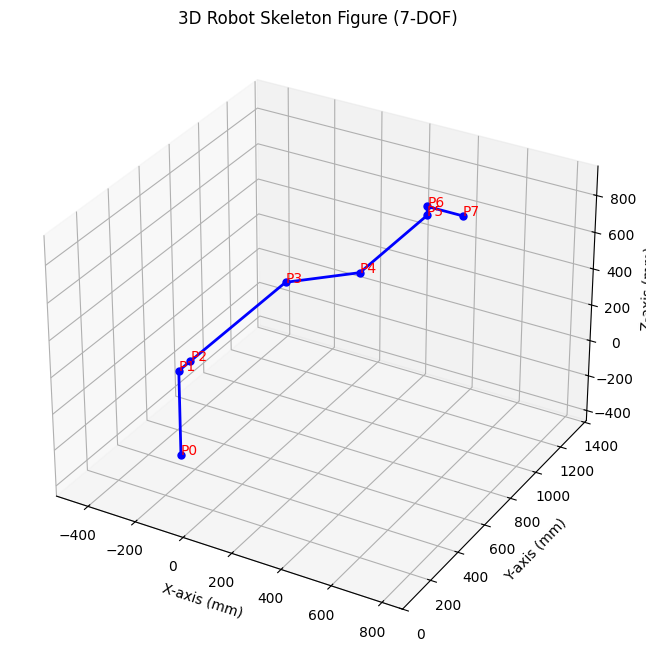

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

alpha = [0, np.pi/2, 0, np.pi/2, 0, -np.pi/2, np.pi/2]
a     = [0, 75, 640, 195, 505, 0, 0]
d     = [450, 0, 0, 195, 0, -50, 150]

symbolic_thetas = {
    'theta1': 0.0,
    'theta2': 0.0,
    'theta3': 0.0,
    'theta4': 0.0,
    'theta5': 0.0,
    'theta6': 0.0,
}

theta_plot = [
    symbolic_thetas['theta1'],
    np.pi/2 + symbolic_thetas['theta2'],
    symbolic_thetas['theta3'],
    symbolic_thetas['theta4'],
    0,
    symbolic_thetas['theta5'],
    np.pi - symbolic_thetas['theta6']
]

def dh_matrix(alpha, a, theta, d):
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    ct = np.cos(theta)
    st = np.sin(theta)
    T = np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0,      sa,     ca,    d],
        [0,       0,      0,    1]
    ])
    return T

joint_origins = [[0, 0, 0]]
T_total = np.eye(4)

for i in range(len(alpha)):
    T_i_to_iplus1 = dh_matrix(alpha[i], a[i], theta_plot[i], d[i])
    T_total = T_total @ T_i_to_iplus1
    origin_iplus1 = T_total[0:3, 3]
    joint_origins.append(origin_iplus1)

joint_origins = np.array(joint_origins)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X = joint_origins[:, 0]
Y = joint_origins[:, 1]
Z = joint_origins[:, 2]

ax.plot(X, Y, Z, color='blue', marker='o', markersize=5, linewidth=2, linestyle='-')

for i in range(len(joint_origins)):
    ax.text(X[i], Y[i], Z[i], f'P{i}', color='red', fontsize=10)

ax.set_xlabel('X-axis (mm)')
ax.set_ylabel('Y-axis (mm)')
ax.set_zlabel('Z-axis (mm)')
ax.set_title('3D Robot Skeleton Figure (7-DOF)')

max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
mid_x = (X.max()+X.min()) / 2.0
mid_y = (Y.max()+Y.min()) / 2.0
mid_z = (Z.max()+Z.min()) / 2.0

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.grid(True)
plt.show()


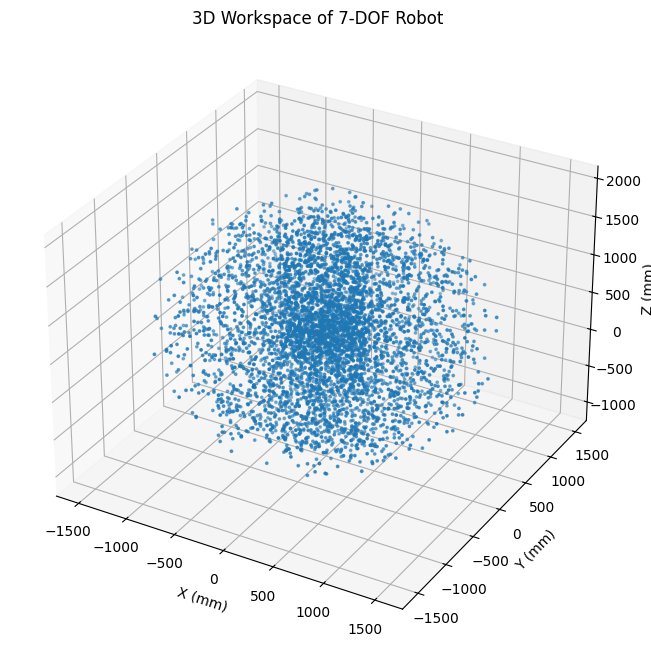

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

alpha = [0, sp.pi/2, 0, sp.pi/2, 0, -sp.pi/2, sp.pi/2]
a     = [0, 75, 640, 195, 505, 0, 0]
d     = [450, 0, 0, 195, 0, -50, 150]

def dh_matrix(a, alpha, d, theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),               np.cos(alpha),               d ],
        [0,              0,                           0,                           1 ]
    ], dtype=float)

def fk(theta_vals):
    T = np.eye(4)
    for i in range(7):
        A = dh_matrix(a[i], float(alpha[i]), d[i], theta_vals[i])
        T = T @ A
    return T[0,3], T[1,3], T[2,3]

N = 5000
points = []

jlimits = [
    (-np.pi, np.pi),
    (-np.pi/2, np.pi/2),
    (-np.pi, np.pi),
    (-np.pi, np.pi),
    (-np.pi, np.pi),
    (-np.pi, np.pi),
]

for _ in range(N):
    th = np.array([np.random.uniform(lo, hi) for lo, hi in jlimits])
    th_full = np.array([
        th[0],
        np.pi/2 + th[1],
        th[2],
        th[3],
        0,
        th[4],
        np.pi - th[5]
    ])
    points.append(fk(th_full))

points = np.array(points)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], s=3)

ax.set_title("3D Workspace of 7-DOF Robot")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

plt.show()


In [6]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt
from numpy import sin, cos, pi

# --- Denavit-Hartenberg (DH) Parameters ---
alpha = np.array([0, pi/2, 0, pi/2, 0, -pi/2, pi/2])
a     = np.array([0, 75, 640, 195, 505, 0, 0])
d     = np.array([450, 0, 0, 195, 0, -50, 150])

DOF = 6
NUM_DH_ROWS = len(alpha)

# --- DH Transformation Matrix Function ---
def dh_matrix(alpha_i, a_i, theta_i, d_i):
    """Calculates the homogeneous transformation matrix A for a single link."""
    c_t, s_t = cos(theta_i), sin(theta_i)
    c_a, s_a = cos(alpha_i), sin(alpha_i)

    A = np.array([
        [c_t, -s_t * c_a,  s_t * s_a,  a_i * c_t],
        [s_t,  c_t * c_a, -c_t * s_a,  a_i * s_t],
        [0,    s_a,        c_a,        d_i      ],
        [0,    0,          0,          1      ]
    ])
    return A

def forward_kinematics(q_in):
    """
    Calculates the end-effector pose T0_N from joint angles q_in.
    Returns 6D pose vector [x, y, z, Roll, Pitch, Yaw].
    """
    # 1. Map the 6 variable joints (q_in) to the 7 DH theta values
    theta_full = np.array([
        q_in[0],
        pi/2 + q_in[1],
        q_in[2],
        q_in[3],
        0,
        q_in[4],
        pi - q_in[5]
    ])

    # 2. Chain the 7 transformations
    T0_N = np.identity(4)
    for j in range(NUM_DH_ROWS):
        A_j = dh_matrix(alpha[j], a[j], theta_full[j], d[j])
        T0_N = T0_N @ A_j

    # 3. Extract the 6D pose vector
    p = T0_N[:3, 3]
    R = T0_N[:3, :3]

    # RPY extraction from Rotation Matrix R (Z-Y-X convention, common for robot wrists)
    if np.abs(R[2, 0]) >= 1.0 - 1e-6:
        # Gimbal lock case
        roll = 0.0
        pitch = np.sign(-R[2, 0]) * pi/2
        yaw = np.arctan2(R[0, 1], R[0, 2]) if pitch > 0 else np.arctan2(-R[0, 1], -R[0, 2])
    else:
        pitch = np.arcsin(-R[2, 0])
        roll = np.arctan2(R[2, 1], R[2, 2])
        yaw = np.arctan2(R[1, 0], R[0, 0])

    rpy = np.array([roll, pitch, yaw])

    return np.concatenate([p, rpy]) # [x, y, z, Roll, Pitch, Yaw]

# --- Inverse Kinematics Implementation ---

def inverse_kinematics_numerical(r_d, q_initial, max_iter=100, tolerance=1e-4):
    """
    Implements the iterative IK algorithm based on the Newton-Raphson method
    (Steps 1-5 from the image) using numerical Jacobian.
    """
    q_i = np.array(q_initial, dtype=float) # Ensure float type
    q_solution = None

    print(f"Target Pose r_d: {r_d}")
    print(f"Starting guess q_0: {np.degrees(q_i)}")
    print("-" * 50)

    for r in range(max_iter):
        # 3. Find J(q_i) (Numerical Jacobian)
        J_qi = np.zeros((DOF, DOF))
        delta = 1e-5

        # Calculate the 6x6 Jacobian J_qi = df/dq
        for k in range(DOF): # For each output component (x, y, z, R, P, Y)

            # --- FIX: Use a lambda to correctly pass the required function to approx_fprime ---
            # The function must take only 'q' and return a single scalar (the k-th output)
            f_k = lambda q: forward_kinematics(q)[k]

            # approx_fprime returns the gradient vector (df_k/dq), which is the k-th row of J
            J_qi[k, :] = approx_fprime(q_i, f_k, delta)
        # -----------------------------------------------------------------------------------

        # Calculate the current end-effector pose f(q_i)
        r_i = forward_kinematics(q_i)

        # Error vector (r_d - r_i)
        error_vector = r_d - r_i

        # 4. Find q_i+1 = q_i + J_inv(q_i) * (r_d - r_i)
        J_inv = np.linalg.pinv(J_qi)

        # Update step (dq)
        delta_q = J_inv @ error_vector

        # Update joint angles
        q_i_plus_1 = q_i + delta_q

        # Normalize joint angles to [-pi, pi] to prevent runaway values
        q_i_plus_1 = np.arctan2(np.sin(q_i_plus_1), np.cos(q_i_plus_1))

        # Calculate the new pose f(q_i+1) for error check
        r_i_plus_1 = forward_kinematics(q_i_plus_1)

        # 5. If |r_d - f(q_i+1)| < E then stop
        error_norm = np.linalg.norm(r_d - r_i_plus_1)

        print(f"Iteration {r+1:02d}: Error Norm = {error_norm:.6f}")

        if error_norm < tolerance:
            print(f"\n✅ SUCCESS! Target reached in {r+1} iterations.")
            q_solution = q_i_plus_1
            break

        q_i = q_i_plus_1

    else:
        print(f"\n❌ FAILURE! Max iterations ({max_iter}) reached. Final Error Norm: {error_norm:.6f}")
        q_solution = q_i # The last calculated joint angles
        r_i_plus_1 = forward_kinematics(q_solution)

    return q_solution, r_i_plus_1

# --- Execution ---

# Target 6D Pose Vector (r_d)
# [x, y, z, Roll, Pitch, Yaw]
R_D = np.array([1000.0, 500.0, 700.0, 0.0, 0.0, 0.0])

# Initial joint angles [t1..t6]
Q_INITIAL = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# 3. Run the IK solver
Q_SOLUTION, R_FINAL = inverse_kinematics_numerical(R_D, Q_INITIAL)

# --- Results ---
if Q_SOLUTION is not None:
    print("\n" + "="*50)
    print("✨ INVERSE KINEMATICS SOLUTION ✨")
    print(f"Target Position:   ({R_D[0]:.2f}, {R_D[1]:.2f}, {R_D[2]:.2f}) mm")
    print(f"Achieved Position: ({R_FINAL[0]:.2f}, {R_FINAL[1]:.2f}, {R_FINAL[2]:.2f}) mm")
    print("-" * 50)
    print("JOINT ANGLES (Radians):")
    print(Q_SOLUTION)
    print("\nJOINT ANGLES (Degrees):")
    print(np.degrees(Q_SOLUTION))
    print("="*50)

Target Pose r_d: [1000.  500.  700.    0.    0.    0.]
Starting guess q_0: [0. 0. 0. 0. 0. 0.]
--------------------------------------------------
Iteration 01: Error Norm = 2085.462208
Iteration 02: Error Norm = 2175.292063
Iteration 03: Error Norm = 1089.514617
Iteration 04: Error Norm = 871.062139
Iteration 05: Error Norm = 1386.014880
Iteration 06: Error Norm = 1627.907037
Iteration 07: Error Norm = 1623.236891
Iteration 08: Error Norm = 1187.476837
Iteration 09: Error Norm = 1581.022623
Iteration 10: Error Norm = 1508.528673
Iteration 11: Error Norm = 920.136537
Iteration 12: Error Norm = 2065.873403
Iteration 13: Error Norm = 1519.144914
Iteration 14: Error Norm = 2213.444634
Iteration 15: Error Norm = 1984.714101
Iteration 16: Error Norm = 536.224842
Iteration 17: Error Norm = 2077.631261
Iteration 18: Error Norm = 2112.211950
Iteration 19: Error Norm = 1772.583659
Iteration 20: Error Norm = 1852.648936
Iteration 21: Error Norm = 1126.244774
Iteration 22: Error Norm = 920.331323


In [7]:
import numpy as np

# ================== Modified DH transform function ======================
def compute_T(a, alpha, theta, d):
    """
    Computes the transformation matrix using Modified DH parameters.
    """
    alpha_rad = np.deg2rad(alpha)
    theta_rad = np.deg2rad(theta)

    Rx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(alpha_rad), -np.sin(alpha_rad), 0],
        [0, np.sin(alpha_rad),  np.cos(alpha_rad), 0],
        [0, 0, 0, 1]
    ])

    Dx = np.array([
        [1, 0, 0, a],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    Rz = np.array([
        [np.cos(theta_rad), -np.sin(theta_rad), 0, 0],
        [np.sin(theta_rad),  np.cos(theta_rad), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    Dz = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, d],
        [0, 0, 0, 1]
    ])

    return Rx @ Dx @ Rz @ Dz


def get_input(prompt, default=0.0):
    """Helper to get float input or return default on Enter"""
    try:
        val = input(prompt)
        return float(val) if val else default
    except ValueError:
        return default


def main():
    print("=================== VELOCITY, ACCELERATION & DYNAMICS ==================\n")
    print("Tip: Press ENTER to use default value (0.0)\n")

    # %% -------------------- USER INPUT : THETA --------------------------------
    print('Enter joint angles (deg):')
    theta_in = []
    for i in range(6):
        theta_in.append(get_input(f'theta{i+1} = '))

    # %% -------------------- USER INPUT : VELOCITY -----------------------------
    print('\nEnter joint velocities (deg/s):')
    qd_deg = []
    for i in range(6):
        qd_deg.append(get_input(f'theta{i+1}_dot = '))
    qd = np.deg2rad(np.array(qd_deg))

    # %% -------------------- USER INPUT : ACCELERATION -------------------------
    print('\nEnter joint accelerations (deg/s^2):')
    qdd_deg = []
    for i in range(6):
        qdd_deg.append(get_input(f'theta{i+1}_ddot = '))
    qdd = np.deg2rad(np.array(qdd_deg))

    # %% -------------------- USER INPUT : BASE VELOCITY/ACC --------------------
    print('\nEnter base linear velocity v0_0 (vx, vy, vz):')
    v0_0 = np.array([get_input('vx0 = '), get_input('vy0 = '), get_input('vz0 = ')])

    print('Enter base angular velocity omega0_0 (wx, wy, wz):')
    omega0_0 = np.array([get_input('wx0 = '), get_input('wy0 = '), get_input('wz0 = ')])

    print('Enter base linear acceleration a0_0 (ax, ay, az):')
    a0_0 = np.array([get_input('ax0 = '), get_input('ay0 = '), get_input('az0 = ')])

    print('Enter base angular acceleration alpha0_0 (ax, ay, az):')
    alpha0_0 = np.array([get_input('alphax0 = '), get_input('alphay0 = '), get_input('alphaz0 = ')])

    # %% -------------------- LINK LENGTHS (REAL ROBOT) -------------------------
    l1 = 400; l2 = 455; l3 = 420; l4 = 90

    # %% -------------------- MODIFIED DH PARAMETERS ----------------------------
    # Arrays aligned for 0-based indexing (Index 0 = Link 1 data)
    a     = [0, 0, l2, 0, 0, 0]
    alpha = [0, 90, 0, -90, 90, -90]
    d     = [l1, 0, 0, l3, 0, l4]

    theta_dh = [
        theta_in[0],
        theta_in[1] + 90,
        theta_in[2] - 90,
        theta_in[3],
        theta_in[4],
        theta_in[5]
    ]

    # %% -------------------- COMPUTE ALL TRANSFORMS ----------------------------
    # Lists to store Rotation (R) and Position (p)
    # index i stores properties of frame i+1 relative to i
    R_i_ip1 = []
    p_i_ip1 = []

    for i in range(6):
        Ti = compute_T(a[i], alpha[i], theta_dh[i], d[i])
        R_i_ip1.append(Ti[0:3, 0:3])
        p_i_ip1.append(Ti[0:3, 3])

    # %% ===================== VELOCITY PROPAGATION =============================
    # Arrays size 3x7 to hold Frames 0 to 6
    v = np.zeros((3, 7))
    w = np.zeros((3, 7))

    v[:, 0] = v0_0
    w[:, 0] = omega0_0

    z_hat = np.array([0, 0, 1])

    for i in range(6):
        # i is current frame, i+1 is next frame
        Ri = R_i_ip1[i]
        pi = p_i_ip1[i]

        R_next_prev = Ri.T  # Transpose

        # v_next
        v_curr = v[:, i]
        w_curr = w[:, i]

        term_v = v_curr + np.cross(w_curr, pi)
        v[:, i+1] = R_next_prev @ term_v

        # w_next
        w[:, i+1] = (R_next_prev @ w_curr) + (qd[i] * z_hat)

    # %% ===================== ACCELERATION PROPAGATION =========================
    acc = np.zeros((3, 7))       # 'a'
    alpha_v = np.zeros((3, 7))   # 'alpha_v'

    acc[:, 0] = a0_0
    alpha_v[:, 0] = alpha0_0

    for i in range(6):
        Ri = R_i_ip1[i]
        pi = p_i_ip1[i]
        R_next_prev = Ri.T

        # Get current values
        w_curr = w[:, i]
        alpha_curr = alpha_v[:, i]
        acc_curr = acc[:, i]

        # Angular Acceleration
        # term = R' * alpha + qdd*z + R'*(w x (qd*z))
        t1 = R_next_prev @ alpha_curr
        t2 = qdd[i] * z_hat
        t3 = R_next_prev @ np.cross(w_curr, qd[i] * z_hat)
        alpha_v[:, i+1] = t1 + t2 + t3

        # Linear Acceleration
        # term = R' * (a + alpha x p + w x (w x p))
        term_a = acc_curr + \
                 np.cross(alpha_curr, pi) + \
                 np.cross(w_curr, np.cross(w_curr, pi))

        acc[:, i+1] = R_next_prev @ term_a

    # %% ===================== LINK MASSES & INERTIAS =================
    # Using the CAD-provided inertias (units in source: TONNE * MM^2 and MASS in TONNE)
    # Conversion: 1 TONNE*MM^2 = 1e-3 kg*m^2  (since 1 tonne = 1000 kg and 1 mm = 1e-3 m)
    #            1 TONNE = 1000 kg

    # ---- MASSES (kg) ----
    # Provided CAD masses for links 1..4, and for links 5..6 we fall back to original small values
    m_link1 = 2.0501517e-02 * 1000.0    # -> kg
    m_link2 = 2.4619090e-02 * 1000.0
    m_link3 = 1.4359432e-03 * 1000.0
    m_link4 = 2.4776694e-02 * 1000.0

    # original smaller link masses (kept for link5 and link6)
    m_link5 = 4.0586884e-03 * 1000.0
    m_link6 = 3.5241968e-04 * 1000.0

    m = np.array([m_link1, m_link2, m_link3, m_link4, m_link5, m_link6])

    # ---- COM positions (m) ----
    # Use CAD center-of-gravity values (converted from mm -> m). The frame mapping is assumed
    # to match the link frames used in the DH table. If your CAD frames differ, replace these
    # with COM in the same frames as the transforms.
    pc = 1e-3 * np.array([
        [0.0, -54.758976, 162.13640, 0.0, 0.0, 0.0],   # x positions (mm -> m)
        [204.77346, 322.98941, 135.01223, 0.0, 0.0, 0.0], # y positions
        [0.0, 0.0, -0.24628939, 251.01023, 0.0, 0.0]     # z positions
    ])

    # ---- Inertia tensors (kg·m^2) ----
    # CAD inertias (TONNE*MM^2) for links 1..4 from your supplied text
    # link1: inertia tensor at CG in _BASE frame (diagonal)
    I1 = np.array([[4.5530915e+02, 0.0, 0.0],
                   [0.0, 5.5243533e+01, 0.0],
                   [0.0, 0.0, 4.5734735e+02]]) * 1e-3

    # link2: inertia tensor at CG in _CURVE frame (has small off-diagonal Ixy)
    I2 = np.array([[1.1941173e+03, -4.0283580e+00, 0.0],
                   [-4.0283580e+00, 8.9774326e+01, 0.0],
                   [0.0, 0.0, 1.2608112e+03]]) * 1e-3

    # link3: inertia tensor at CG in _SIDE frame (full symmetric tensor)
    I3 = np.array([[9.8910893e+00, -9.3007510e+00, 1.4365575e+00],
                   [-9.3007510e+00, 1.1324324e+01, 1.4352061e+00],
                   [1.4365575e+00, 1.4352061e+00, 1.9750171e+01]]) * 1e-3

    # link4: inertia tensor at CG in _LAST frame (diagonal)
    I4 = np.array([[5.5505437e+02, 0.0, 0.0],
                   [0.0, 5.5503745e+02, 0.0],
                   [0.0, 0.0, 6.9415947e+01]]) * 1e-3

    # For links 5 and 6 we use the original CAD-derived diagonal inertias scaled the same way
    I5 = np.diag([1.0976370e+01, 1.1098693e+01, 6.8549813e+00]) * 1e-3
    I6 = np.diag([1.8880362e-01, 2.1913528e-01, 1.8880342e-01]) * 1e-3

    Ic = [I1, I2, I3, I4, I5, I6]

    # ----------------- Assumption note -------------------------------------
    # The CAD inertias are given in their local CAD frames (_BASE, _CURVE, _SIDE, _LAST).
    # The code below assumes those CAD frames align with the kinematic frames used by the
    # DH parameters. If that is not true, you must rotate each inertia tensor into the
    # corresponding DH frame using: I_frame = R_cad_to_frame @ I_cad @ R_cad_to_frame.T
    # where R_cad_to_frame is the rotation matrix from CAD frame to DH frame.
    # ------------------------------------------------------------------------

    # %% ===================== COM ACCELERATION, Fi, Ni =========================
    ac = np.zeros((3, 6))
    Fi = np.zeros((3, 6))
    Ni = np.zeros((3, 6))

    for i in range(6):
        # Velocity/Acc from propagation (column i+1)
        wi     = w[:, i+1]
        alphai = alpha_v[:, i+1]
        ai     = acc[:, i+1]

        pci    = pc[:, i]  # COM for this link (in meters)
        Ici    = Ic[i]     # Inertia for this link (kg*m^2)

        # a_com = a + alpha x pc + w x (w x pc)
        ac[:, i] = ai + np.cross(alphai, pci) + np.cross(wi, np.cross(wi, pci))

        # Force/Moment (Newton-Euler)
        Fi[:, i] = m[i] * ac[:, i]
        Ni[:, i] = (Ici @ alphai) + np.cross(wi, (Ici @ wi))

    # %% ===================== BACKWARD NEWTON–EULER ============================
    f_joint = np.zeros((3, 7))
    n_joint = np.zeros((3, 7))

    # No external wrench at end-effector (Frame 6 / Index 6)
    f_joint[:, 6] = np.zeros(3)
    n_joint[:, 6] = np.zeros(3)

    # Loop backwards: 5, 4, 3, 2, 1, 0
    # Corresponds to Link 6 down to Link 1
    for i in range(5, -1, -1):
        Ri   = R_i_ip1[i]
        Ri_T = Ri.T
        pi   = p_i_ip1[i]

        # Get values from next link (i+1)
        f_next = f_joint[:, i+1]
        n_next = n_joint[:, i+1]

        # Inertial force of current link (i)
        Fi_curr = Fi[:, i]
        Ni_curr = Ni[:, i]

        # f_i = R' * f_{i+1} + Fi
        f_curr = (Ri_T @ f_next) + Fi_curr
        f_joint[:, i] = f_curr

        # n_i = R' * n_{i+1} + p x f_i + Ni
        n_curr = (Ri_T @ n_next) + np.cross(pi, f_curr) + Ni_curr
        n_joint[:, i] = n_curr

    # %% ------------------ COMPUTE JOINT TORQUES -------------------------------
    tau = np.zeros(6)

    # Joint torques are the Z-component of the moment vector n_joint
    for i in range(6):
        tau[i] = n_joint[:, i] @ z_hat

    # %% ------------------ INERTIAL FORCES & MOMENTS ---------------------------
    # Link-level inertial forces/moments (Reaction)
    Finertial_link = -Fi
    Ninertial_link = -Ni

    # Joint-level inertial forces/moments (Reaction)
    Finertial_joint = -f_joint[:, 0:6]
    Ninertial_joint = -n_joint[:, 0:6]

    # %% ------------------ PRINT RESULTS ---------------------------------------
    print("\n============== JOINT TORQUES (tau1..tau6) ==================")
    for i in range(6):
        print(f"tau{i+1} = {tau[i]:.4f} N·m")

    print("\n============== JOINT INERTIAL FORCES (base frame) ==========")
    for i in range(6):
        F = Finertial_joint[:, i]
        print(f"Joint {i+1} inertial force = [{F[0]:.4f}  {F[1]:.4f}  {F[2]:.4f}] N")

    print("\n============== JOINT INERTIAL MOMENTS (base frame) =========")
    for i in range(6):
        N = Ninertial_joint[:, i]
        print(f"Joint {i+1} inertial moment = [{N[0]:.4f}  {N[1]:.4f}  {N[2]:.4f}] N·m")


if __name__ == "__main__":
    main()


=================== VELOCITY, ACCELERATION & DYNAMICS ==================

Tip: Press ENTER to use default value (0.0)

Enter joint angles (deg):
theta1 = 0
theta2 = 0
theta3 = 0
theta4 = 0
theta5 = 0
theta6 = 0

Enter joint velocities (deg/s):
theta1_dot = 1
theta2_dot = 1
theta3_dot = 1
theta4_dot = 1
theta5_dot = 1
theta6_dot = 1

Enter joint accelerations (deg/s^2):
theta1_ddot = 1
theta2_ddot = 2
theta3_ddot = 2
theta4_ddot = 2
theta5_ddot = 2
theta6_ddot = 2

Enter base linear velocity v0_0 (vx, vy, vz):
vx0 = 3
vy0 = 3
vz0 = 3
Enter base angular velocity omega0_0 (wx, wy, wz):
wx0 = 3
wy0 = 4
wz0 = 4
Enter base linear acceleration a0_0 (ax, ay, az):
ax0 = 4
ay0 = 4
az0 = 4
Enter base angular acceleration alpha0_0 (ax, ay, az):
alphax0 = 5
alphay0 = 5
alphaz0 = 5

============== JOINT TORQUES (tau1..tau6) ==================
tau1 = -37440365.2216 N·m
tau2 = -37440362.7155 N·m
tau3 = 7420454.5936 N·m
tau4 = -265645799.2010 N·m
tau5 = -0.0320 N·m
tau6 = -732802.4338 N·m

============